In [5]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [6]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.fc1   = nn.Linear(16 * 7 * 7, 64)
        self.fc2   = nn.Linear(64, 10)
        self.pool  = nn.MaxPool2d(2)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_data = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")

Train size: 60000
Test size: 10000


In [8]:
model_fashion = TinyNet()

optimizer = torch.optim.Adam(model_fashion.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model_fashion(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 1 | Loss: 0.5367
Epoch 2 | Loss: 0.3504
Epoch 3 | Loss: 0.3064
Epoch 4 | Loss: 0.2769
Epoch 5 | Loss: 0.2571


In [9]:
torch.save(model_fashion.state_dict(), 'tinynet_fashion_baseline.pth')
print("FashionMNIST baseline saved!")

FashionMNIST baseline saved!


In [10]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            output = model(images)
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Accuracy: {100 * correct / total:.2f}%")

evaluate(model_fashion, test_loader)

Accuracy: 89.70%


In [15]:
def Load_fresh_fashion_model():
    model = TinyNet()
    model.load_state_dict(torch.load('tinynet_fashion_baseline.pth'))
    model.eval()
    return model
def prune_model(model,amount):
    prune.l1_unstructured(model.conv1, name='weight',amount=amount)
    prune.l1_unstructured(model.conv2, name='weight',amount=amount)
    prune.l1_unstructured(model.fc1, name='weight',amount=amount)
    prune.l1_unstructured(model.fc2, name='weight',amount=amount)
    return model
def evalauate(model,test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images,label in test_loader:
            output = model(images)
            _, predicted  = torch.max(output,1)
            total += label.size(0)
            correct += (predicted == labels).sum().items
    print(f"Accuracy: {100 * correct / total:.2f}%")



FINDING FashionMNIST CLIFF!!

In [16]:
sparsity_level  = [0.2, 0.4, 0.6, 0.65, 0.7, 0.8]
for amount in  sparsity_level:
    model_fashion = Load_fresh_fashion_model()
    model_fashion = prune_model(model_fashion, amount)
    print(f"Sparsity: {int(amount*100)}%", end=" | ")
    evaluate(model_fashion, test_loader)
    print("---")
    

Sparsity: 20% | Accuracy: 89.28%
---
Sparsity: 40% | Accuracy: 87.20%
---
Sparsity: 60% | Accuracy: 74.86%
---
Sparsity: 65% | Accuracy: 69.87%
---
Sparsity: 70% | Accuracy: 58.88%
---
Sparsity: 80% | Accuracy: 29.38%
---


In [19]:
sparsity_level  = [0.01, 0.12, 0.14, 0.16, 0.18]
for amount in  sparsity_level:
    model_fashion = Load_fresh_fashion_model()
    model_fashion = prune_model(model_fashion, amount)
    print(f"Sparsity: {int(amount*100)}%", end=" | ")
    evaluate(model_fashion, test_loader)
    print("---")

Sparsity: 1% | Accuracy: 89.70%
---
Sparsity: 12% | Accuracy: 89.48%
---
Sparsity: 14% | Accuracy: 89.38%
---
Sparsity: 16% | Accuracy: 89.52%
---
Sparsity: 18% | Accuracy: 89.49%
---


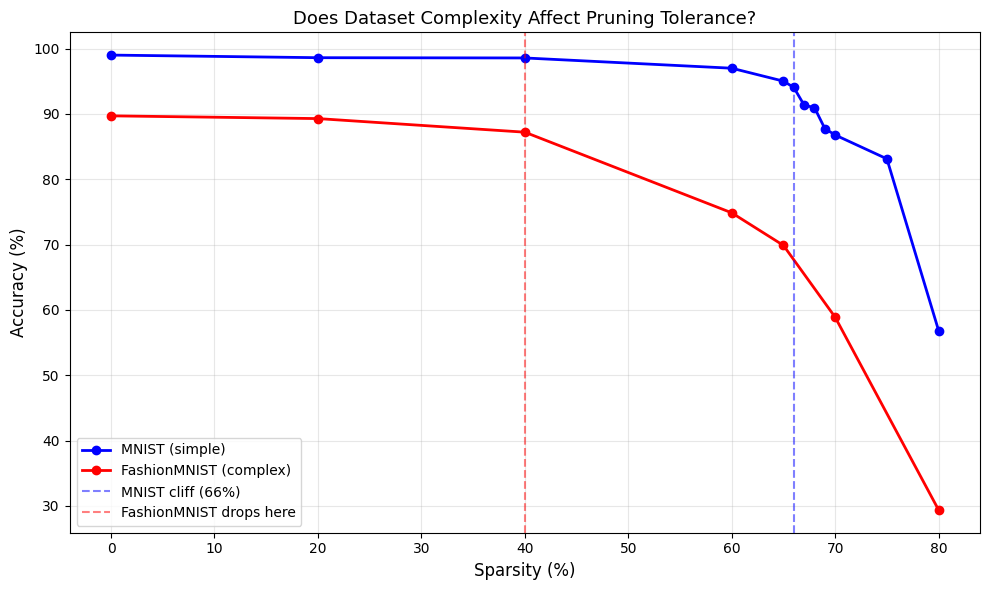

Graph saved!


In [20]:
import matplotlib.pyplot as plt

# MNIST results
mnist_sparsity = [0, 20, 40, 60, 65, 66, 67, 68, 69, 70, 75, 80]
mnist_accuracy = [99, 98.60, 98.56, 96.99, 95.01, 94.05, 91.34, 90.96, 87.75, 86.77, 83.12, 56.83]

# FashionMNIST results
fashion_sparsity = [0, 20, 40, 60, 65, 70, 80]
fashion_accuracy = [89.70, 89.28, 87.20, 74.86, 69.87, 58.88, 29.38]

plt.figure(figsize=(10, 6))
plt.plot(mnist_sparsity, mnist_accuracy, 'b-o', label='MNIST (simple)', linewidth=2)
plt.plot(fashion_sparsity, fashion_accuracy, 'r-o', label='FashionMNIST (complex)', linewidth=2)
plt.axvline(x=66, color='blue', linestyle='--', alpha=0.5, label='MNIST cliff (66%)')
plt.axvline(x=40, color='red', linestyle='--', alpha=0.5, label='FashionMNIST drops here')
plt.xlabel('Sparsity (%)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Does Dataset Complexity Affect Pruning Tolerance?', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mnist_vs_fashion_pruning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved!")